# Bank Customer Churn Dataset - Data Preprocessing

This notebook performs a standard preprocessing workflow for the **Bank Customer Churn** dataset.

## Goals
- inspect the dataset
- check data quality
- remove non-predictive identifier columns
- encode categorical variables
- split the data into train and test sets
- scale numeric features for models such as **Logistic Regression** and **SVM**
- save the processed files for model training

> Target column: **Exited**


In [33]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


## 1. Load the dataset

In [34]:
df = pd.read_csv("../data/raw/Churn_Modelling.csv")

## 2. Basic inspection

In [35]:
print("Shape of dataset:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Shape of dataset: (10000, 14)

Column names:
['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Data types:
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing values:
RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0


## 3. Understand the target variable

In [36]:
print(df['Exited'].value_counts())
print("\nClass proportions:")
print(df['Exited'].value_counts(normalize=True).round(4))


Exited
0    7963
1    2037
Name: count, dtype: int64

Class proportions:
Exited
0    0.7963
1    0.2037
Name: proportion, dtype: float64


## 4. Drop identifier / non-predictive columns

These columns are removed because they do not meaningfully help prediction:

- **RowNumber**: just row index information
- **CustomerId**: unique customer identifier
- **Surname**: customer name-like text with very high cardinality

Keeping these can add noise and reduce model quality.


In [37]:
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df.drop(columns=columns_to_drop)

df_clean.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## 5. Outlier Analysis

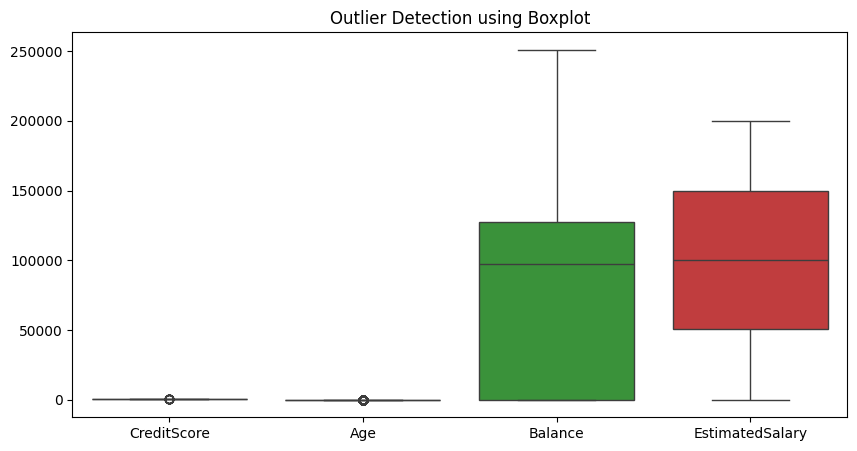

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.boxplot(data=df[['CreditScore','Age','Balance','EstimatedSalary']])
plt.title("Outlier Detection using Boxplot")
plt.show()

## 6. Separate features and target

In [39]:
X = df_clean.drop('Exited', axis=1)
y = df_clean['Exited']

print("Feature shape:", X.shape)
print("Target shape:", y.shape)


Feature shape: (10000, 10)
Target shape: (10000,)


## 7. Identify categorical and numerical columns

In [40]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)


Categorical columns: ['Geography', 'Gender']
Numerical columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


## 8. Train-test split

We use **stratify=y** to preserve the churn / non-churn class ratio in both train and test sets.


In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (8000, 10)
X_test : (2000, 10)
y_train: (8000,)
y_test : (2000,)


## 9. Build preprocessing pipelines

### Numerical columns
- impute missing values with median
- scale using `StandardScaler`

### Categorical columns
- impute missing values with most frequent value
- encode with `OneHotEncoder`

This is the **standard and safer** preprocessing approach for this dataset.


In [42]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['CreditScore', 'Age', 'Tenure', 'Balance',
                                  'NumOfProducts', 'HasCrCard',
                                  'IsActiveMember', 'EstimatedSalary']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Geography', 'Gender'])])

## 10. Fit preprocessing on training data only

This avoids **data leakage**.


In [43]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed X_train shape:", X_train_processed.shape)
print("Processed X_test shape :", X_test_processed.shape)


Processed X_train shape: (8000, 13)
Processed X_test shape : (2000, 13)


## 11. Convert processed arrays back to DataFrames

In [44]:
# Get final feature names after one-hot encoding
cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(cat_feature_names)

X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns=all_feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=all_feature_names,
    index=X_test.index
)

X_train_processed_df.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
2151,1.058568,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,1.0,0.0,0.0,0.0,1.0
8392,0.913626,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,0.0,1.0,0.0,0.0,1.0
5006,1.079274,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,0.0,1.0,0.0,1.0,0.0
4117,-0.929207,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,1.0,0.0,0.0,0.0,1.0
7182,0.427035,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,0.0,1.0,0.0,0.0,1.0


## 12. Final processed training and testing datasets

In [45]:
train_processed = X_train_processed_df.copy()
train_processed['Exited'] = y_train.values

test_processed = X_test_processed_df.copy()
test_processed['Exited'] = y_test.values

print("Processed training set:")
display(train_processed.head())

print("Processed test set:")
display(test_processed.head())


Processed training set:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Exited
2151,1.058568,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,1.0,0.0,0.0,0.0,1.0,1
8392,0.913626,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,0.0,1.0,0.0,0.0,1.0,1
5006,1.079274,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,0.0,1.0,0.0,1.0,0.0,0
4117,-0.929207,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,1.0,0.0,0.0,0.0,1.0,0
7182,0.427035,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,0.0,1.0,0.0,0.0,1.0,0


Processed test set:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Exited
5702,-0.680735,-0.279932,0.684723,-1.226059,0.808830,0.641042,-1.030206,-0.095021,1.0,0.0,0.0,0.0,1.0,0
3667,-1.301915,-0.564935,-0.350971,0.877113,0.808830,-1.559960,-1.030206,-0.778941,0.0,1.0,0.0,0.0,1.0,0
1617,-0.970619,0.100072,-0.350971,-1.226059,0.808830,-1.559960,0.970680,0.099469,0.0,0.0,1.0,1.0,0.0,0
5673,-0.121674,-0.469934,-0.005739,1.011458,0.808830,-1.559960,-1.030206,-1.147374,0.0,0.0,1.0,0.0,1.0,0
4272,-0.111321,-0.469934,-0.696202,0.023204,-0.910256,0.641042,0.970680,1.200283,0.0,0.0,1.0,1.0,0.0,0


## 13. Save processed files

In [46]:
from pathlib import Path

output_dir = Path("../data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

df.to_csv(output_dir / "churn_processed.csv", index=False)

print("Saved file:", (output_dir / "churn_processed.csv").resolve())

Saved file: E:\ML01\bank_customer_churn_prediction-ml\data\processed\churn_processed.csv


## 14. Notes

### Why this preprocessing is correct for your dataset
- there are **no missing values**, but imputation steps are kept for robustness
- there are **no duplicate rows**
- `RowNumber`, `CustomerId`, and `Surname` are dropped because they are not strong predictive features in a standard churn model
- `Geography` and `Gender` are categorical, so **One-Hot Encoding** is preferred
- scaling is useful for **Logistic Regression** and **SVM**
- this processed data can be directly used for:
  - Logistic Regression
  - SVM
  - Decision Tree
  - Random Forest

### Important note
For **Decision Tree** and **Random Forest**, scaling is not strictly required, but keeping one common processed dataset is convenient for comparison across models.
